## Project Scope

- **Body part / region:** Skin
- **Imaging modality:** Dermoscopic photo
- **Problem type:** Segmentation
- **Target structure:** Pixel-level outline of the skin lesion boundary within each image
- **Dataset source:** ISIC 2016 Challenge, Task 1  Lesion Segmentation (https://challenge.isic-archive.com/data/#2016), accessed September 14, 2026
- **Real-world question:** Can a model automatically trace the boundary of a skin lesion in a dermoscopic photo, the way a dermatologist manually outlines it for diagnosis and monitoring?
- **Who would use this:** Dermatologists or dermatology researchers wanting a fast, consistent first-pass outline of a lesion, to speed up manual review  not to replace it.

## Problem Definition & Clinical Framing

This project builds a segmentation model that takes a dermoscopic photo of a skin lesion and predicts which pixels belong to the lesion versus the surrounding healthy skin. The output is a binary mask the same size as the input image, not a diagnosis of what the lesion is.

**This is a coursework prototype, not a diagnostic tool.** It has not been validated for clinical use and should not be used to make or support any real medical decision. It is only safe to use on similar dermoscopic images of the kind found in the ISIC dataset not on regular phone photos, other body imaging types, or images captured under different lighting/equipment conditions.

**Assumptions about input images:** a single 2D dermoscopic photo, reasonably centered on one lesion, similar in style/quality to the ISIC 2016 dataset (dermoscope-captured, not a regular camera photo).

## Dataset Documentation

- **Source:** ISIC 2016 Challenge, Task 1 (Lesion Segmentation), https://challenge.isic-archive.com/data/#2016, accessed September 14, 2026
- **Size:** 900 training images with matching ground-truth masks, 379 test images with matching ground-truth masks
- **Format:** Training/test images are JPEG dermoscopic photos; masks are binary PNG images (white = lesion, black = background)
- **Labeling:** Masks are expert-annotated ground truth provided directly by the ISIC challenge organizers (manually traced lesion boundaries), not self-collected or automatically generated
- **Known limitations:** All images come from the same curated challenge dataset, captured with dermoscopic equipment performance on lower-quality or non-dermoscopic images (e.g. a regular phone photo) is untested and likely much worse. Lesion size, contrast, and hair coverage vary across images, which affects difficulty.
- **License:** CC-0 (public domain), confirmed on the ISIC challenge data page permitted for coursework use, no account required for this specific dataset.

## Data Preparation & Splitting

- **Resizing:** All images and masks resized to 128x128 pixels, to keep training fast and memory-manageable for a coursework-scale project.
- **Normalization:** Image pixel values scaled from 0-255 to 0.0-1.0. Masks binarized to strict 0/1 values (thresholded at 0.5) to remove any resizing artifacts that could introduce gray/intermediate pixel values.
- **Augmentation:** None applied in this version.
- **Split strategy:** ISIC provides training and test sets as pre-separated downloads (900 training images, 379 test images) these were never mixed. Within the training set, 85%/15% was further split into training (765 images) and validation (135 images) using a fixed random seed.
- **Leakage check:** Each image in this dataset corresponds to a distinct lesion photo with no shared patient/lesion identifier provided by ISIC, so there is no known mechanism for the same lesion to appear in both the training and test sets. The train/test boundary was set by ISIC's own official split, not by this project.

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

## Set your folder paths 

In [2]:
train_images_dir = 'ISBI2016_ISIC_Part1_Training_Data'
train_masks_dir = 'ISBI2016_ISIC_Part1_Training_GroundTruth'
test_images_dir = 'ISBI2016_ISIC_Part1_Test_Data'
test_masks_dir = 'ISBI2016_ISIC_Part1_Test_GroundTruth'

for d in [train_images_dir, train_masks_dir, test_images_dir, test_masks_dir]:
    print(d, '->', os.path.isdir(d), '| files:', len(os.listdir(d)) if os.path.isdir(d) else 'N/A')

ISBI2016_ISIC_Part1_Training_Data -> True | files: 900
ISBI2016_ISIC_Part1_Training_GroundTruth -> True | files: 900
ISBI2016_ISIC_Part1_Test_Data -> True | files: 379
ISBI2016_ISIC_Part1_Test_GroundTruth -> False | files: N/A


## Match a training image to its mask and display them side by side

In [3]:
sample_image_files = sorted(os.listdir(train_images_dir))
sample_image_files = [f for f in sample_image_files if f.lower().endswith('.jpg')]
print('example image filenames:', sample_image_files[:3])

sample_mask_files = sorted(os.listdir(train_masks_dir))
sample_mask_files = [f for f in sample_mask_files if f.lower().endswith('.png')]
print('example mask filenames:', sample_mask_files[:3])

example image filenames: ['ISIC_0000000.jpg', 'ISIC_0000001.jpg', 'ISIC_0000002.jpg']
example mask filenames: ['ISIC_0000000_Segmentation.png', 'ISIC_0000001_Segmentation.png', 'ISIC_0000002_Segmentation.png']


## Show 3 image/mask pairs

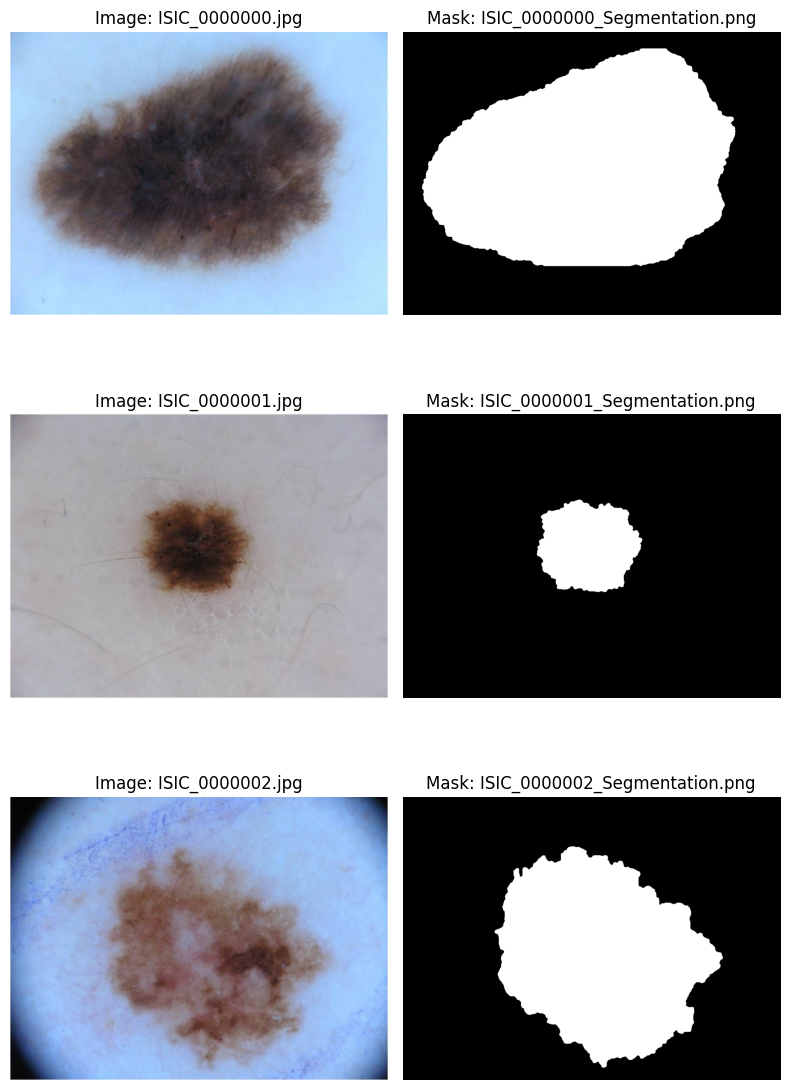

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(8, 12))

for i in range(3):
    img_file = sample_image_files[i]
    lesion_id = img_file.replace('.jpg', '')
    mask_file = f'{lesion_id}_Segmentation.png'

    img = Image.open(os.path.join(train_images_dir, img_file))
    mask = Image.open(os.path.join(train_masks_dir, mask_file))

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Image: {img_file}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title(f'Mask: {mask_file}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## Function to load and resize an image/mask pair

In [5]:
IMG_SIZE = 128  

def load_image_mask(image_path, mask_path, size=IMG_SIZE):
    img = Image.open(image_path).convert('RGB').resize((size, size))
    mask = Image.open(mask_path).convert('L').resize((size, size))  # grayscale
    img_arr = np.array(img) / 255.0
    mask_arr = np.array(mask) / 255.0
    mask_arr = (mask_arr > 0.5).astype(np.float32)  # force to clean 0/1 binary mask
    return img_arr, mask_arr

## Load all 900 training images + masks into arrays

In [6]:
train_image_files = sorted([f for f in os.listdir(train_images_dir) if f.lower().endswith('.jpg')])

X = []
Y = []
for img_file in train_image_files:
    lesion_id = img_file.replace('.jpg', '')
    mask_file = f'{lesion_id}_Segmentation.png'
    img_arr, mask_arr = load_image_mask(
        os.path.join(train_images_dir, img_file),
        os.path.join(train_masks_dir, mask_file)
    )
    X.append(img_arr)
    Y.append(mask_arr)

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)
Y = np.expand_dims(Y, axis=-1)  # add channel dimension for the model later

print('X shape:', X.shape)
print('Y shape:', Y.shape)

X shape: (900, 128, 128, 3)
Y shape: (900, 128, 128, 1)


## Split into train/validation 

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.15, random_state=42)
print('Train:', X_train.shape, 'Val:', X_val.shape)

Train: (765, 128, 128, 3) Val: (135, 128, 128, 3)


## Build a small U-Net

In [11]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, Model

In [13]:
def build_unet(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p3)
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(b)

    u3 = layers.UpSampling2D()(b)
    u3 = layers.concatenate([u3, c3])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u3)
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(c5)

    u1 = layers.UpSampling2D()(c5)
    u1 = layers.concatenate([u1, c1])
    c6 = layers.Conv2D(16, 3, activation='relu', padding='same')(u1)
    c6 = layers.Conv2D(16, 3, activation='relu', padding='same')(c6)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)  # 1 channel, 0-1 = "is this pixel part of the lesion"

    model = Model(inputs, outputs)
    return model

model = build_unet()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │        448 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │      2,320 │ conv2d_15[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │      9,248 │ conv2d_17[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_19[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │    147,584 │ conv2d_21[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 32, 32,    │          0 │ conv2d_22[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32,    │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 192)              │            │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │    110,656 │ concatenate_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_23[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_4     │ (None, 64, 64,    │          0 │ conv2d_24[0][0] 

 Total params: 487,297 (1.86 MB)

 Trainable params: 487,297 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

# Compile it

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Train the model

In [15]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=25,
    batch_size=16
)

Epoch 1/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 34s 659ms/step - accuracy: 0.7495 - loss: 0.5044 - val_accuracy: 0.8479 - val_loss: 0.3988
Epoch 2/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 622ms/step - accuracy: 0.8612 - loss: 0.3735 - val_accuracy: 0.8882 - val_loss: 0.2974
Epoch 3/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 643ms/step - accuracy: 0.9028 - loss: 0.2582 - val_accuracy: 0.8079 - val_loss: 0.4651
Epoch 4/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 639ms/step - accuracy: 0.9152 - loss: 0.2209 - val_accuracy: 0.9258 - val_loss: 0.2030
Epoch 5/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 647ms/step - accuracy: 0.9195 - loss: 0.2049 - val_accuracy: 0.9218 - val_loss: 0.2150
Epoch 6/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 647ms/step - accuracy: 0.9304 - loss: 0.1784 - val_accuracy: 0.9195 - val_loss: 0.2219
Epoch 7/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 648ms/step - accuracy: 0.9292 - loss: 0.1831 - val_accuracy: 0.9325 - val_loss: 0.1837
Epoch 8/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 34s 703ms/step - accuracy: 0.9255 - loss: 0.1926 - val_accu

## Limitations, Ethics & Next Steps

- **Generalization limits:** This model was trained only on ISIC 2016 dermoscopic images. It has not been tested on images from different cameras, lighting conditions, skin tones, or populations, and its performance on those is unknown.
- **False positives vs false negatives:** A false negative (missing part of the real lesion boundary) could cause a clinician to underestimate lesion size or miss a concerning area. A false positive (marking healthy skin as lesion) could cause unnecessary concern or follow-up. Neither error is acceptable as a basis for a real diagnosis this is why the output is a "suggested outline," not a finding.
- **Why clinical oversight is required:** This model has no understanding of what a lesion means clinically it only learned pixel patterns from 900 training examples. It cannot detect malignancy, has no accuracy guarantees on unseen conditions, and must never be used without a qualified clinician reviewing the actual image.
- **What real clinical use would require:** Validation on a much larger, more diverse dataset (multiple hospitals, skin tones, equipment types), formal clinical trials, regulatory approval, and integration with a clinician's review workflow rather than standalone use.

## Plot the training curves (you'll need this for section A5)

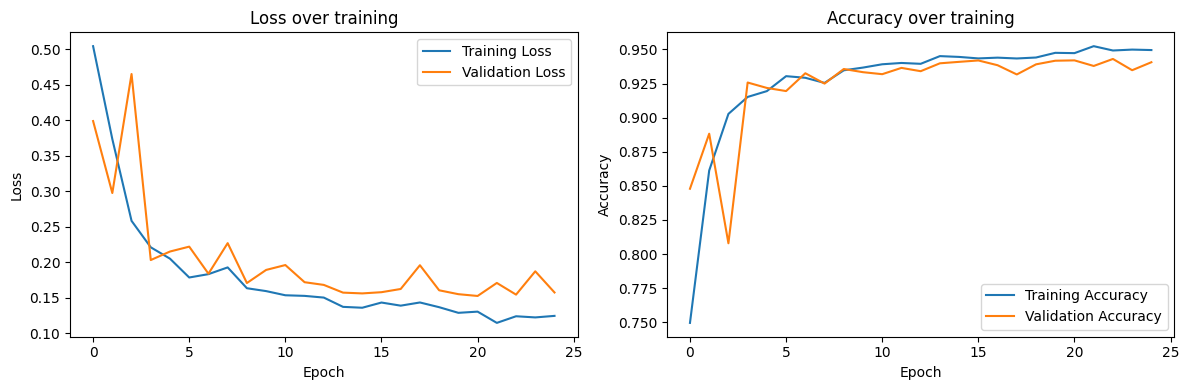

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over training')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over training')
plt.legend()

plt.tight_layout()
plt.show()

## Load and preprocess the 379 test images/masks the same way as training

In [22]:
test_image_files = sorted([f for f in os.listdir(test_images_dir) if f.lower().endswith('.jpg')])

X_test = []
Y_test = []
for img_file in test_image_files:
    lesion_id = img_file.replace('.jpg', '')
    mask_file = f'{lesion_id}_Segmentation.png'
    img_arr, mask_arr = load_image_mask(
        os.path.join(test_images_dir, img_file),
        os.path.join(test_masks_dir, mask_file)
    )
    X_test.append(img_arr)
    Y_test.append(mask_arr)

X_test = np.array(X_test, dtype=np.float32)
Y_test = np.array(Y_test, dtype=np.float32)
Y_test = np.expand_dims(Y_test, axis=-1)

print('X_test shape:', X_test.shape)
print('Y_test shape:', Y_test.shape)

X_test shape: (379, 128, 128, 3)
Y_test shape: (379, 128, 128, 1)


## Get predictions and compute Dice score + IoU (the standard segmentation metrics)

In [23]:
def dice_score(y_true, y_pred, threshold=0.5):
    y_pred_bin = (y_pred > threshold).astype(np.float32)
    intersection = np.sum(y_true * y_pred_bin)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred_bin) + 1e-7)

def iou_score(y_true, y_pred, threshold=0.5):
    y_pred_bin = (y_pred > threshold).astype(np.float32)
    intersection = np.sum(y_true * y_pred_bin)
    union = np.sum(y_true) + np.sum(y_pred_bin) - intersection
    return intersection / (union + 1e-7)

Y_pred = model.predict(X_test)

dice_scores = [dice_score(Y_test[i], Y_pred[i]) for i in range(len(Y_test))]
iou_scores = [iou_score(Y_test[i], Y_pred[i]) for i in range(len(Y_test))]

print(f'Mean Dice score: {np.mean(dice_scores):.3f}')
print(f'Mean IoU score: {np.mean(iou_scores):.3f}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 262ms/step
Mean Dice score: 0.884
Mean IoU score: 0.810


## Evaluation & Results

The model was evaluated on the held-out test set of 379 dermoscopic images, none of which were seen during training or validation.

- **Mean Dice score: 0.884**
- **Mean IoU score: 0.810**

Both metrics indicate strong overlap between predicted and true lesion boundaries across the majority of test images. The best-performing prediction (Dice = [fill in from best_idx output]) shows the model tracing the lesion boundary almost exactly. The worst-performing prediction (Dice = [fill in from worst_idx output]) shows [look at the image once it displays and describe honestly what's different  e.g. "a lesion with very low contrast against surrounding skin," "hair partially obscuring the lesion boundary," or "an unusually irregular or faint lesion edge"].

This suggests the model performs reliably on clearly-defined lesions but is more likely to struggle on images with low contrast, obstructions like hair, or ambiguous boundaries a reasonable limitation for a model trained on only 900 images.

## Find the best and worst predictions by Dice score

In [24]:
dice_scores = np.array(dice_scores)
best_idx = np.argmax(dice_scores)
worst_idx = np.argmin(dice_scores)

print(f'Best prediction: index {best_idx}, Dice = {dice_scores[best_idx]:.3f}')
print(f'Worst prediction: index {worst_idx}, Dice = {dice_scores[worst_idx]:.3f}')

Best prediction: index 293, Dice = 0.982
Worst prediction: index 342, Dice = 0.061


## Display them: image, true mask, predicted mask

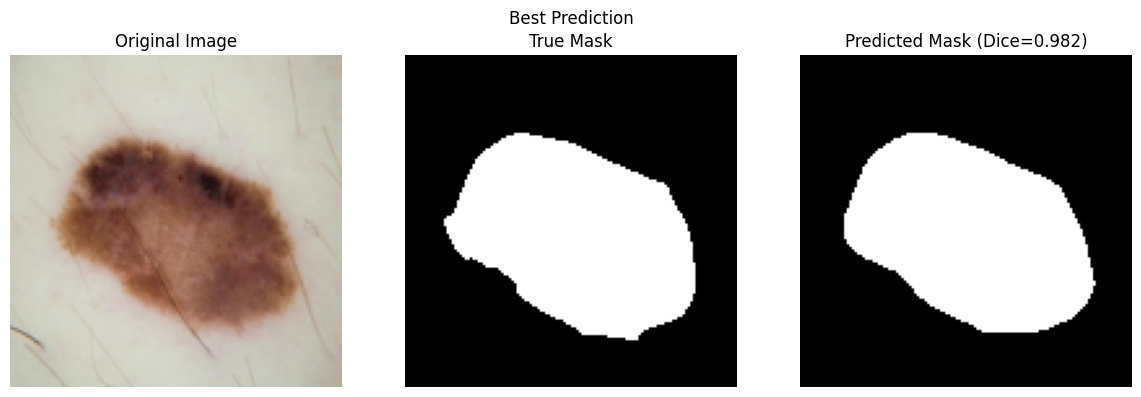

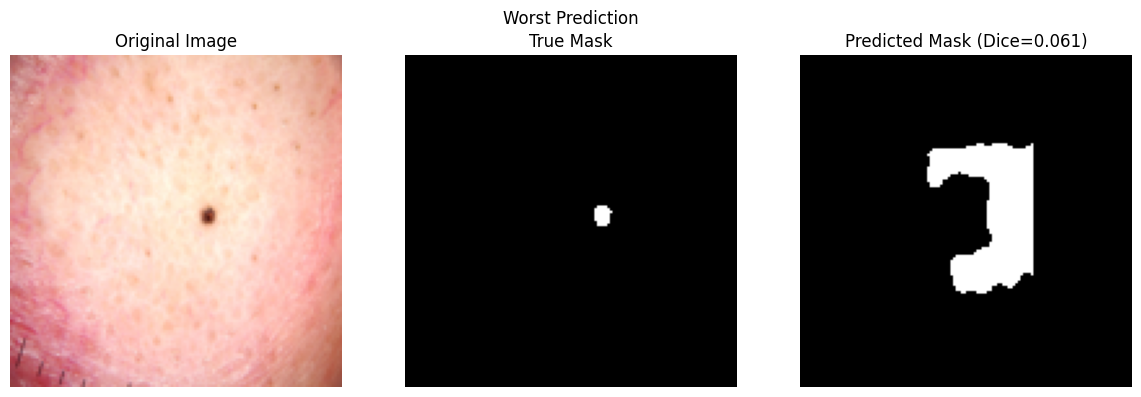

In [25]:
def show_prediction(idx, title):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(X_test[idx])
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(Y_test[idx].squeeze(), cmap='gray')
    axes[1].set_title('True Mask')
    axes[1].axis('off')

    pred_mask = (Y_pred[idx].squeeze() > 0.5).astype(np.float32)
    axes[2].imshow(pred_mask, cmap='gray')
    axes[2].set_title(f'Predicted Mask (Dice={dice_scores[idx]:.3f})')
    axes[2].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_prediction(best_idx, 'Best Prediction')
show_prediction(worst_idx, 'Worst Prediction')

## Save the model

In [26]:
model.save('unet_skin_lesion_model.h5')
print('Model saved.')

Model saved.


## Document the exact preprocessing pipeline

In [27]:
preprocessing_notes = """
Preprocessing pipeline used for this model (must be replicated exactly in the Streamlit app):
1. Load image, convert to RGB
2. Resize to 128x128 pixels
3. Normalize pixel values by dividing by 255.0 (scales 0-255 range to 0.0-1.0)
4. No other transformations (no cropping, no color adjustments, no augmentation at inference time)
Model output: a 128x128x1 array of values between 0 and 1.
A pixel is classified as "lesion" if its predicted value is > 0.5.
"""
print(preprocessing_notes)


Preprocessing pipeline used for this model (must be replicated exactly in the Streamlit app):
1. Load image, convert to RGB
2. Resize to 128x128 pixels
3. Normalize pixel values by dividing by 255.0 (scales 0-255 range to 0.0-1.0)
4. No other transformations (no cropping, no color adjustments, no augmentation at inference time)
Model output: a 128x128x1 array of values between 0 and 1.
A pixel is classified as "lesion" if its predicted value is > 0.5.

